# Sentiment Analysis for Mental Health Monitoring

In [1]:
import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP & Text
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Misc
warnings.filterwarnings("ignore")

# Ensure necessary downloads
nltk.download('punkt_tab')
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
data = pd.read_csv('Combined Data.csv', index_col=0) # drops the initial index column
data

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [3]:
data[data['statement'].isna() == True].shape

(362, 2)

In [4]:
data.dropna(inplace=True)

In [5]:
data

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [6]:
print(f"Unique statements: {data['statement'].nunique()}")
print(f"Unique statuses: {data['status'].nunique()}")
print(Counter(data['status']))

Unique statements: 51073
Unique statuses: 7
Counter({'Normal': 16343, 'Depression': 15404, 'Suicidal': 10652, 'Anxiety': 3841, 'Bipolar': 2777, 'Stress': 2587, 'Personality disorder': 1077})


In [7]:
statuses = data['status'].unique()

Most common words for Anxiety : [('anxiety', 3725), ('like', 3276), ('feel', 2284), ('get', 1984), ('know', 1852), ('time', 1630), ('really', 1603), ('something', 1274), ('back', 1267), ('even', 1223), ('going', 1187), ('go', 1184), ('one', 1179), ('feeling', 1167), ('health', 1153)]


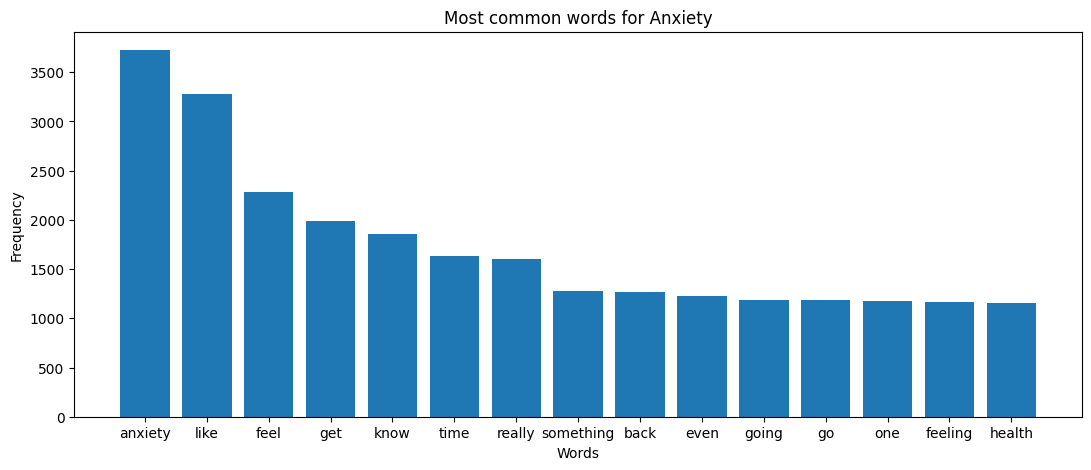

Most common words for Normal : [('like', 1235), ('want', 1120), ('get', 874), ('really', 860), ('time', 809), ('one', 757), ('go', 755), ('know', 736), ('good', 677), ('would', 651), ('people', 643), ('day', 616), ('work', 584), ('going', 561), ('still', 531)]


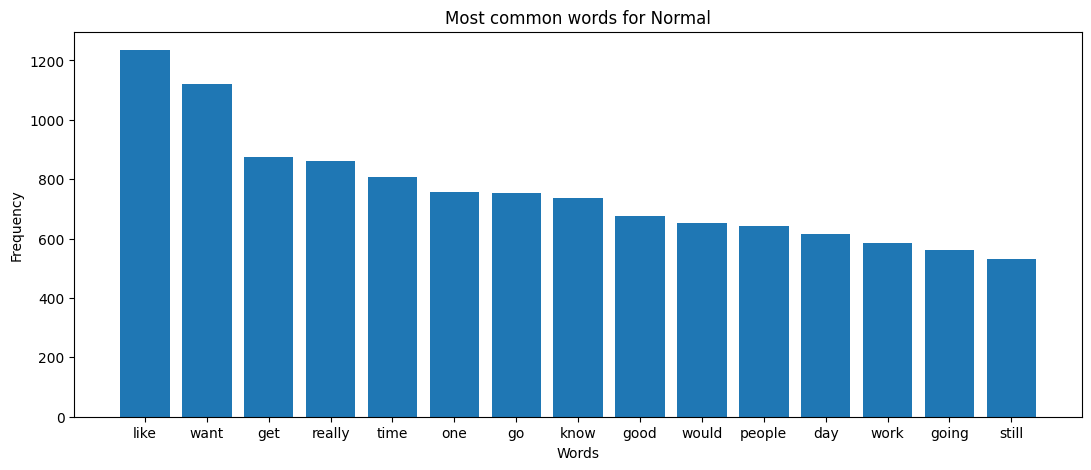

Most common words for Depression : [('like', 18277), ('feel', 16539), ('want', 12124), ('life', 11130), ('know', 10833), ('get', 9992), ('even', 9171), ('time', 8318), ('people', 7903), ('would', 7418), ('really', 7200), ('one', 6398), ('depression', 6378), ('going', 5946), ('day', 5674)]


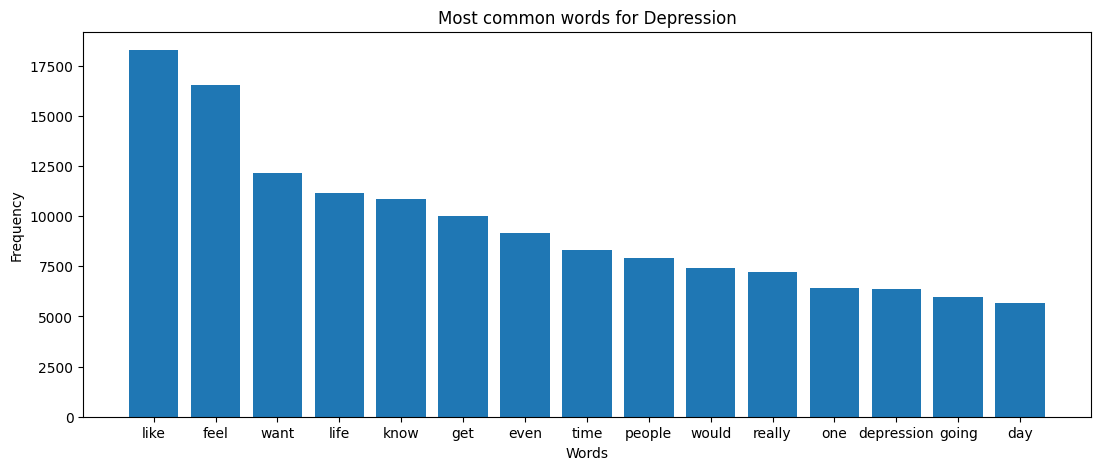

Most common words for Suicidal : [('want', 10640), ('like', 9116), ('life', 7700), ('feel', 7520), ('know', 6545), ('would', 5729), ('get', 5223), ('even', 5180), ('people', 4754), ('anymore', 4416), ('going', 4269), ('time', 4179), ('one', 4144), ('think', 3883), ('really', 3854)]


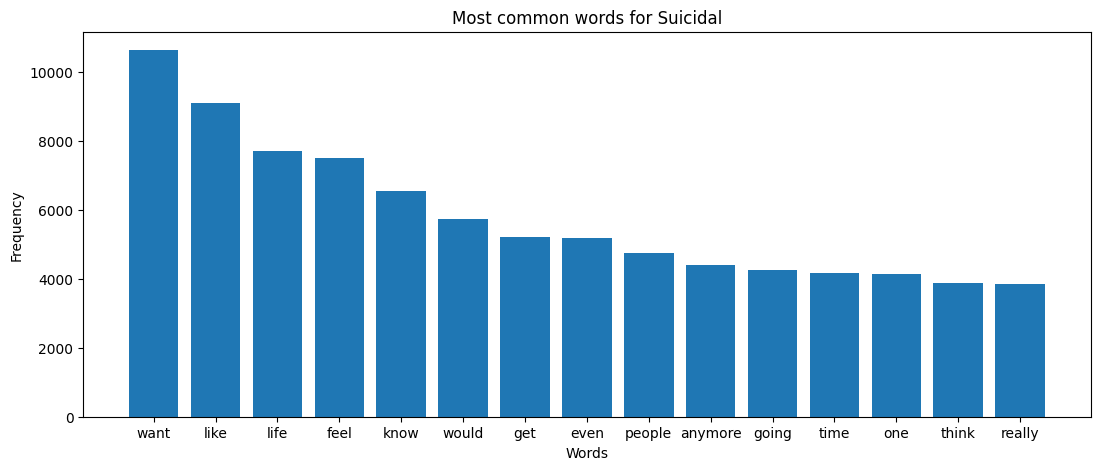

Most common words for Stress : [('like', 1725), ('stress', 1490), ('feel', 1338), ('get', 1207), ('know', 1023), ('time', 1011), ('even', 805), ('work', 790), ('really', 773), ('help', 706), ('life', 654), ('anxiety', 646), ('would', 626), ('want', 623), ('one', 598)]


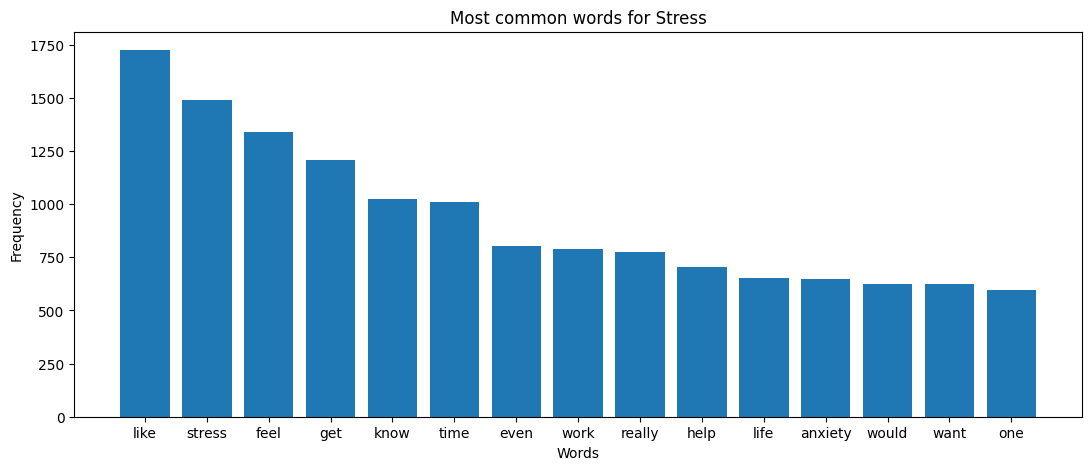

Most common words for Bipolar : [('like', 3028), ('feel', 2388), ('bipolar', 1837), ('get', 1814), ('know', 1787), ('time', 1496), ('really', 1494), ('want', 1306), ('even', 1107), ('life', 1098), ('one', 1075), ('would', 1074), ('anyone', 1025), ('going', 1006), ('people', 981)]


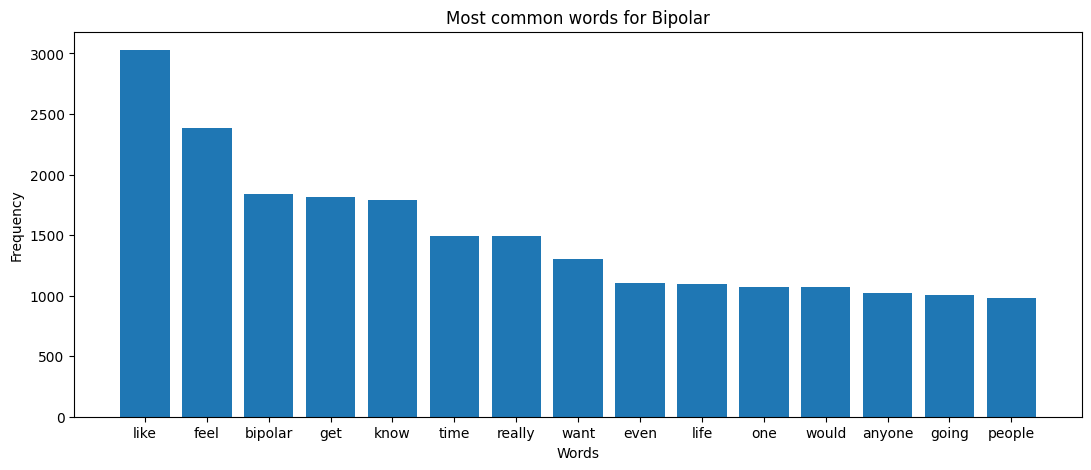

Most common words for Personality disorder : [('like', 1680), ('people', 1248), ('feel', 1101), ('even', 795), ('know', 788), ('get', 637), ('want', 626), ('avpd', 602), ('life', 600), ('really', 596), ('think', 578), ('one', 538), ('time', 522), ('would', 511), ('never', 474)]


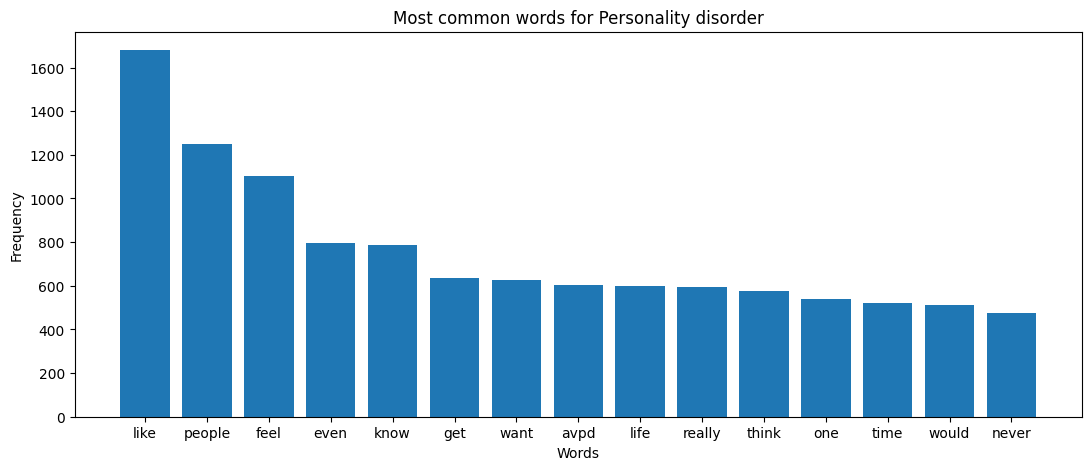

In [8]:
stop_words = set(stopwords.words("english"))

def get_word_freq(status):
    text = " ".join(data[data['status']==status]['statement'])
    words = word_tokenize(text.lower())
    words_filtered = [word for word in words if word.isalpha() and word not in stop_words]
    word_freq = Counter(words_filtered)
    return word_freq

for status in statuses:
    word_freq = get_word_freq(status)
    most_common_words = word_freq.most_common(15)
    print(f"Most common words for {status} : {most_common_words}")

    word, count = zip(*most_common_words)
    plt.figure(figsize = (13,5))
    plt.bar(word, count)
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.title(f"Most common words for {status}")
    plt.show()

## Analysis of Most Common Words Across Different Mental Health Conditions

The following is an analysis of the most common words used in statements categorized by various mental health conditions. These insights provide a glimpse into the emotional state and focus of individuals experiencing different conditions.

### 1. **Anxiety**
   - **Top Words**: `anxiety`, `feel`, `know`, `something`
   - **Key Insights**: The word "anxiety" is the most frequently used, indicating that individuals often explicitly mention their anxiety. Words like "feel" and "know" suggest a focus on personal emotions and thoughts. The use of the word "something" could imply uncertainty or vague concerns.

### 2. **Normal**
   - **Top Words**: `like`, `want`, `good`, `day`
   - **Key Insights**: In contrast to the other conditions, the "Normal" category contains more positive and neutral words like "good" and "day." Words like "want" and "like" indicate a focus on desires and preferences rather than emotional distress.

### 3. **Depression**
   - **Top Words**: `feel`, `life`, `depression`, `even`
   - **Key Insights**: The prominence of words like "feel" and "life" suggests that individuals with depression are heavily focused on their internal emotional state and the broader concept of life. The frequent use of the word "depression" indicates that individuals are explicitly naming their condition.

### 4. **Suicidal**
   - **Top Words**: `want`, `life`, `feel`, `anymore`
   - **Key Insights**: The appearance of the word "anymore" signals a loss of hope or a desire for something to end, which aligns with the condition. There is also a strong focus on "life" and "want," reflecting a deep contemplation of existence and desires.

### 5. **Stress**
   - **Top Words**: `stress`, `feel`, `help`, `work`
   - **Key Insights**: "Stress" is directly mentioned, which highlights the specific nature of the concern. The use of words like "help" indicates that individuals are seeking support or relief from their stress. "Work" also appears, suggesting that work-related issues may be a significant source of stress.

### 6. **Bipolar**
   - **Top Words**: `bipolar`, `feel`, `even`, `anyone`
   - **Key Insights**: The word "bipolar" is explicitly mentioned, indicating self-awareness of the condition. Words like "anyone" suggest a potential feeling of isolation or a desire to connect with others who might understand.

### 7. **Personality Disorder**
   - **Top Words**: `people`, `feel`, `avpd`, `never`
   - **Key Insights**: "People" is a frequent word, which could imply a focus on interpersonal relationships or social interactions. The acronym "avpd" refers to `Avoidant Personality Disorder`, indicating specific concerns related to this disorder. The word "never" suggests feelings of hopelessness or permanence.

### General Observations
- **Common Themes**: Across multiple conditions, words like "feel," "like," and "want" appear consistently, which reflects a focus on personal emotions and desires.
- **Specific Words**: Certain conditions feature specific words related to their diagnosis, such as "anxiety," "depression," "bipolar," and "stress," indicating that individuals are explicitly discussing their mental health.
- **Emotional Focus**: The words reveal that individuals often focus on their feelings, their life circumstances, and their interactions with others, which are common threads in mental health discussions.


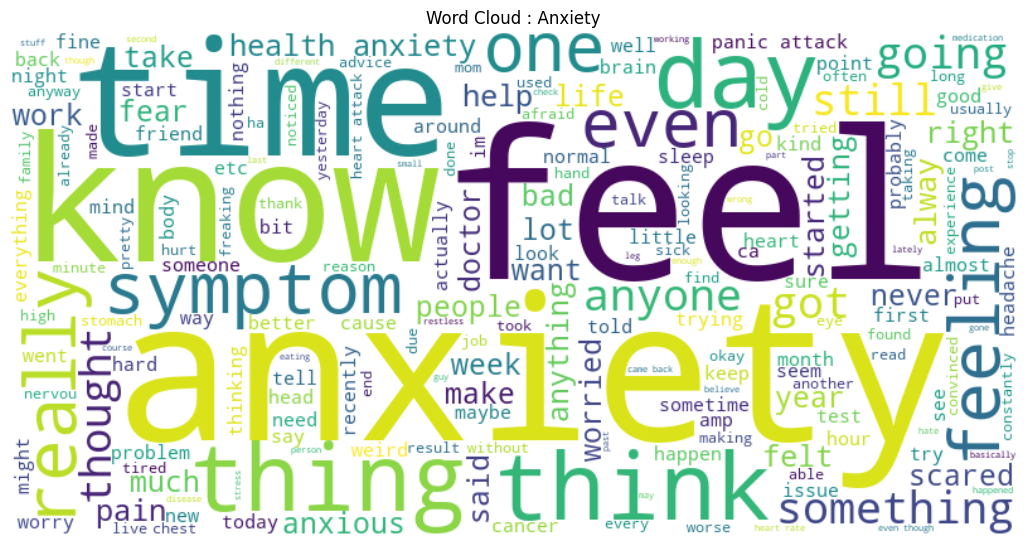

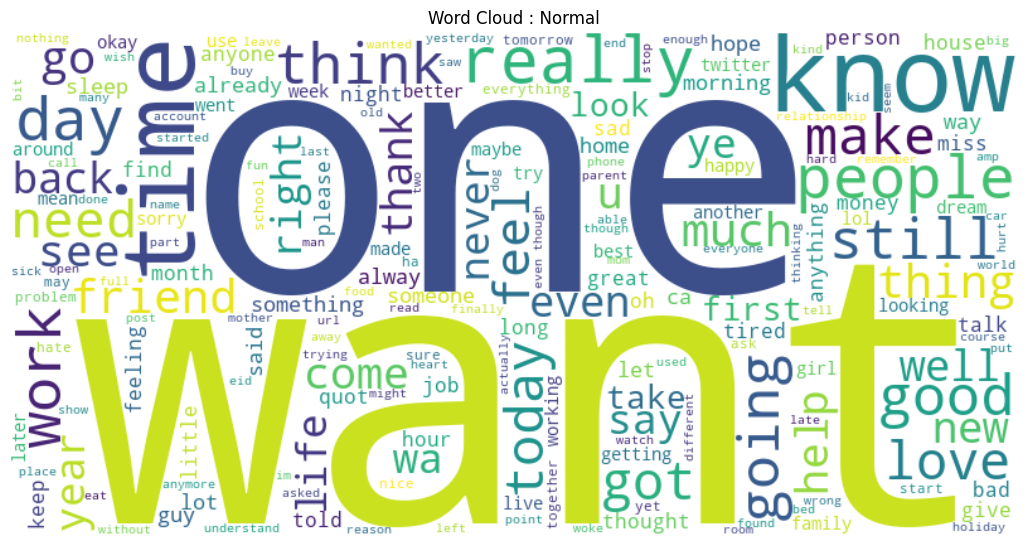

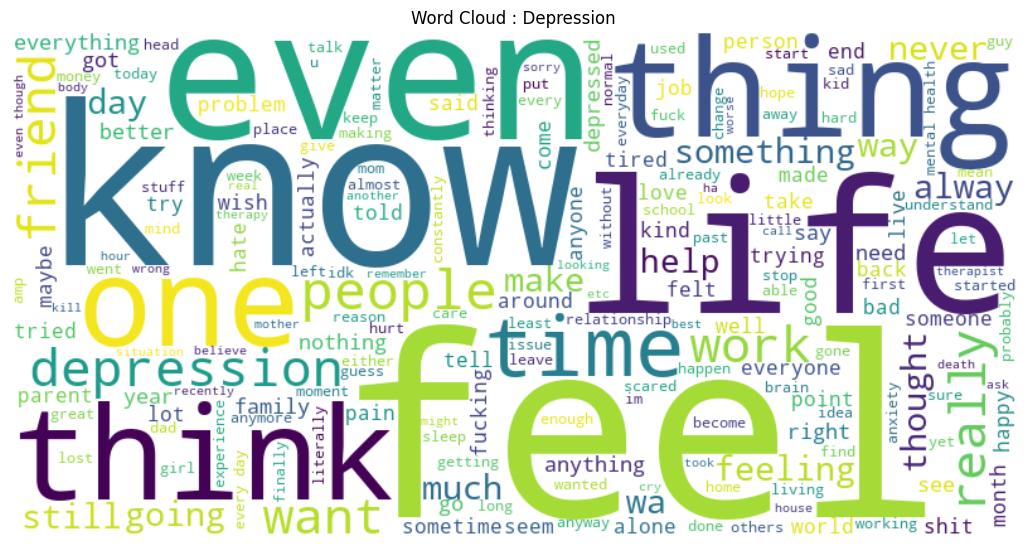

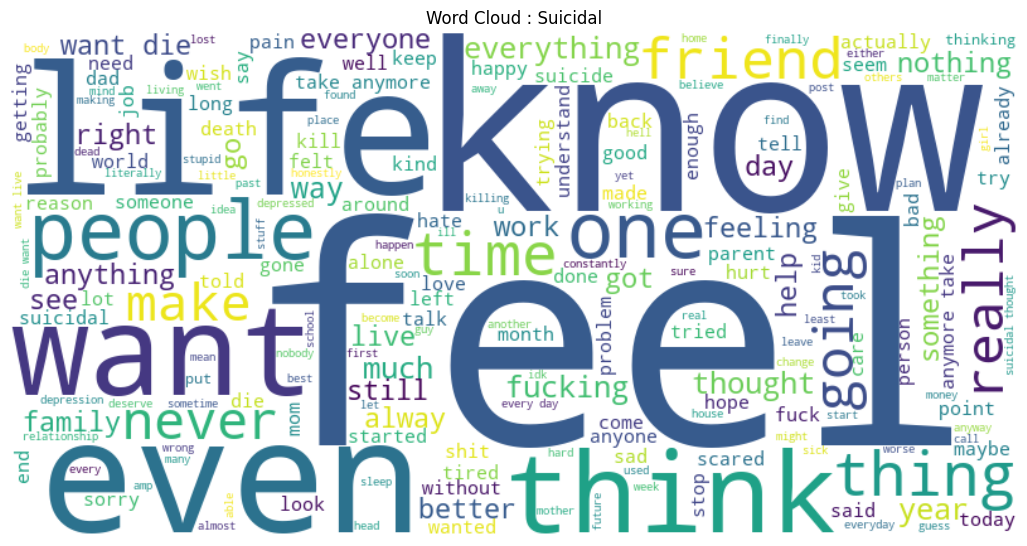

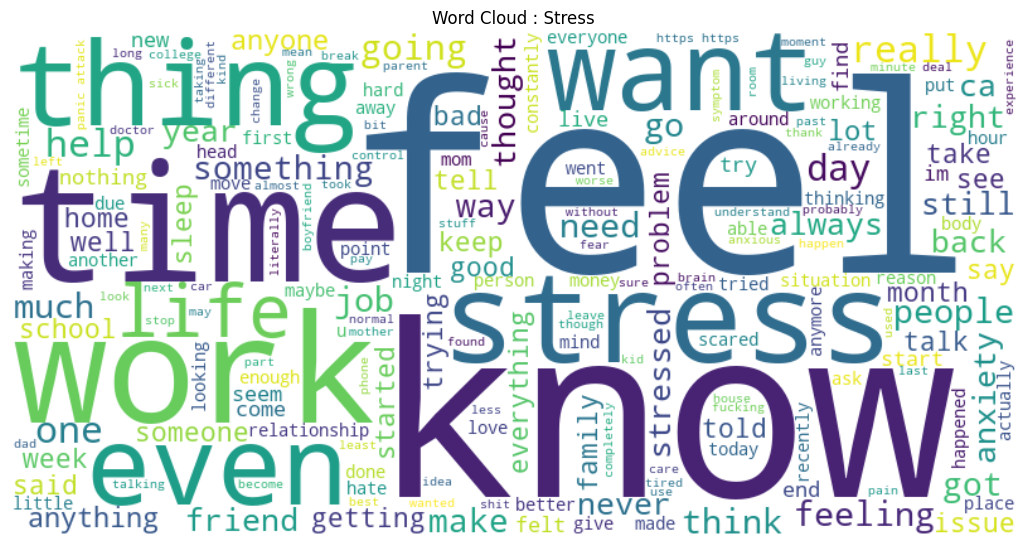

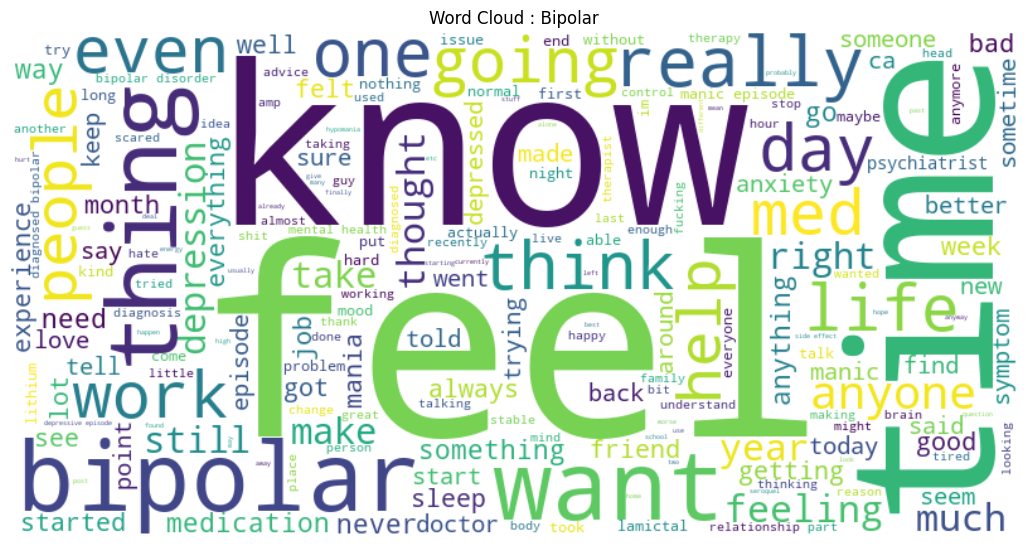

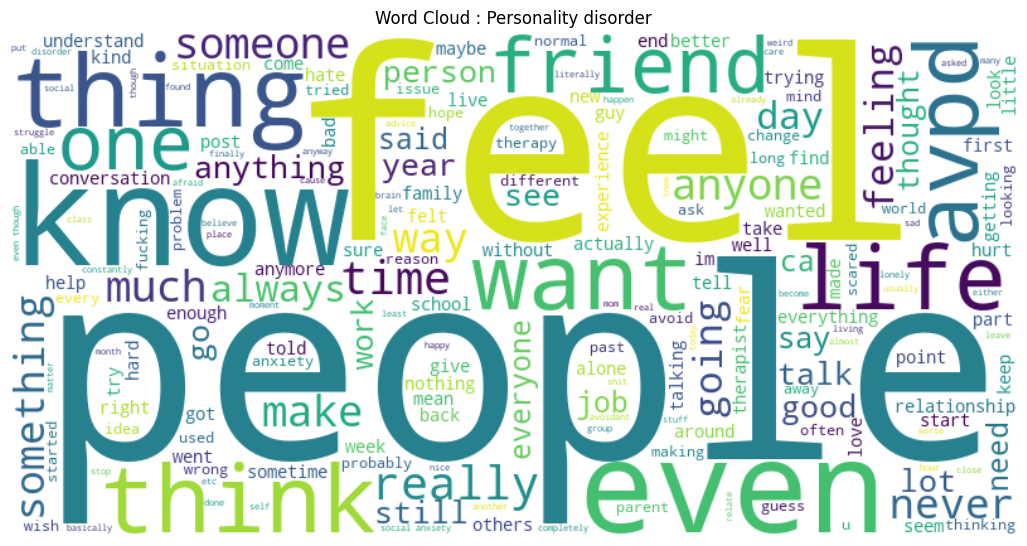

In [9]:
from wordcloud import WordCloud

def generate_word_clouds(status):
    text = " ".join(data[data['status']==status]['statement'])
    words = word_tokenize(text.lower())
    words_filtered = [word for word in words if word.isalpha() and word not in stop_words]
    text = " ".join(words_filtered)

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(13,7))
    plt.imshow(wordcloud, interpolation = "bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud : {status}")
    plt.show()

for status in statuses:
    generate_word_clouds(status)

# Analysis of Mental Health Word Clouds

## Overview
The word clouds represent key terms associated with various mental health conditions:
1. Anxiety
2. Normal (baseline)
3. Depression
4. Suicidal thoughts
5. Stress
6. Bipolar disorder
7. Personality disorder

## Common Themes

Across all conditions, certain words appear frequently:
- "feel/feeling"
- "think/thinking"
- "know"
- "want"
- "time"
- "people"

This suggests that mental health experiences often revolve around cognitive processes, emotions, and social interactions.

## Condition-Specific Insights

### Anxiety
- Dominated by "anxiety", "feel", "think"
- Notable words: "panic", "attack", "scared", "symptom"
- Indicates a focus on physical sensations and worry

### Normal (Baseline)
- More positive terms: "love", "hope", "dream"
- Balanced mix of everyday words
- Less emphasis on extreme emotions or struggles

### Depression
- Key words: "depression", "feel", "know", "want"
- Noteworthy: "never", "nothing", "fucking" (indicating frustration)
- Suggests feelings of hopelessness and negativity

### Suicidal Thoughts
- Prominent: "want", "life", "die"
- Concerning terms: "kill", "suicide", "pain"
- Reflects severe distress and thoughts of self-harm

### Stress
- Centered on "feel", "want", "know"
- Notable: "work", "time", "school"
- Indicates external pressures as major contributors

### Bipolar Disorder
- Key terms: "bipolar", "manic", "depression"
- Unique words: "episode", "medication", "psychiatrist"
- Reflects the cyclical nature of the condition and medical intervention

### Personality Disorder
- Prominent: "feel", "people", "think"
- Specific term: "BPD" (likely Borderline Personality Disorder)
- Suggests interpersonal difficulties and emotional instability

## Implications for NLP and Sentiment Analysis

1. Feature Extraction: Use prominent words as key features for classification models.
2. Emotion Detection: Identify words associated with specific emotional states.
3. Severity Assessment: Analyze word choice to gauge the intensity of mental health challenges.
4. Topic Modeling: Group related terms to identify sub-themes within each condition.
5. Contextual Analysis: Understand the unique linguistic patterns for each mental health state.
6. Intervention Flags: Identify critical terms (e.g., in the suicidal thoughts cloud) for urgent intervention.?

In [10]:
def preprocess_text(text):
    """Lowercase, clean, tokenize, remove stopwords, and lemmatize."""
    text = re.sub(r'[^a-z\s]', '', text.lower())
    tokens = [t for t in word_tokenize(text) if t not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

In [11]:
data["processed_statement"] = data["statement"].apply(preprocess_text)

encoder = LabelEncoder()
data["status"] = encoder.fit_transform(data["status"])
print(encoder.classes_)

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']


In [12]:
train_df, test_df = train_test_split(data, test_size=0.2, shuffle=True, random_state=42)

In [13]:
class_counts = {}
for x in train_df['status'].unique():
    class_counts[x] = train_df[train_df['status']==x].shape[0]
    print(x, train_df[train_df['status']==x].shape[0])

6 8494
2 12388
4 840
5 2051
3 13035
0 3086
1 2250


In [14]:
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace('_', ' ')
            if synonym != word:
                synonyms.add(synonym)
    return list(synonyms)

In [15]:
def random_insertion(sentence: str, n=2) -> str:
    """Insert random synonyms into the sentence."""
    words = sentence.split()
    for _ in range(n):
        candidates = get_synonyms(random.choice(words)) if words else []
        if candidates:
            new_word = random.choice(candidates)
            idx = random.randint(0, len(words))
            words.insert(idx, new_word)
    return " ".join(words)

In [16]:
def random_swap(sentence: str, n=2) -> str:
    """Randomly swap words in a sentence."""
    words = sentence.split()
    if len(words) < 2:
        return sentence
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return " ".join(words)

In [17]:
def synonym_replacement(sentence: str, n_replacements=1) -> str:
    """Replace n random words with their synonyms."""
    words = sentence.split()
    if not words:
        return sentence

    new_sentence = words.copy()
    
    # Get synonyms for each word in the sentence
    synonyms = {word: get_synonyms(word) for word in words if get_synonyms(word)}

    replacements = 0
    while replacements < n_replacements and synonyms:
        word_to_replace = random.choice(list(synonyms.keys()))
        choices = list(synonyms[word_to_replace])
        if choices:
            synonym = random.choice(choices)
            new_sentence = [synonym if w == word_to_replace else w for w in new_sentence]
            replacements += 1
        synonyms.pop(word_to_replace)

    return " ".join(new_sentence)

In [18]:
# class_counts = {0: 3086, 1: 2250, 2: 12388, 3: 13035, 4: 840, 5: 2051, 6: 8494}

def augment_minority_classes(train_df: pd.DataFrame, threshold=5000) -> pd.DataFrame:
    """Balance minority classes with synonym-based augmentation."""
    augmented_samples = []

    class_counts = train_df["status"].value_counts().to_dict()

    for label, count in class_counts.items():
        if count < threshold:
            minority_df = train_df[train_df["status"] == label]
            n_to_generate = threshold - count

            for _ in range(n_to_generate):
                sentence = random.choice(minority_df["processed_statement"].tolist())
                new_sentence = synonym_replacement(sentence)
                augmented_samples.append({
                    "statement": sentence,
                    "processed_statement": new_sentence,
                    "status": label
                })

    if augmented_samples:
        augmented_df = pd.DataFrame(augmented_samples)
        train_df = pd.concat([train_df, augmented_df], ignore_index=True)

    return train_df


def augment_with_insertion_swap(train_df: pd.DataFrame, minority_labels: list, n=2) -> pd.DataFrame:
    """Apply random insertion and swap augmentations to minority classes."""

    def apply_aug(df, func):
        subset = df[df["status"].isin(minority_labels)].copy()
        subset["processed_statement"] = subset["processed_statement"].apply(lambda x: func(x, n))
        return subset

    insertion_aug = apply_aug(train_df, random_insertion)
    swap_aug = apply_aug(train_df, random_swap)

    return pd.concat([train_df, insertion_aug, swap_aug], ignore_index=True)


# --- Augmentation Pipeline ---
train_df = augment_minority_classes(train_df, threshold=5000)
minority_labels = [0, 1, 4, 5]
train_df = augment_with_insertion_swap(train_df, minority_labels)

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

Train shape: (93917, 3), Test shape: (10537, 3)


In [19]:
for x in train_df['status'].unique():
    print(x, train_df[train_df['status']==x].shape[0])

6 8494
2 12388
4 15000
5 15000
3 13035
0 15000
1 15000


In [20]:
train_df

,statement,status,processed_statement
0,I know it seems like such a stupid reason to d...,6,know seems like stupid reason decide maybe rig...
1,every night i son and cry and promise myself t...,2,every night son cry promise tell parent need t...
2,It's getting harder to pretend I'll be okay My...,4,getting harder pretend ill okay birthday last ...
3,My brother was diagnosed with MDD w/ to psycho...,2,brother diagnosed mdd w psychotic feature mont...
4,Post grad application and butter fingers I app...,5,post grad application butter finger applied ma...
...,...,...,...
93912,feel like leech sometimes song stop track one ...,4,feel like leech sometimes song stop track one ...
93913,deal inperson avoidance hi dear community ques...,4,hold inperson avoidance hi dear community ques...
93914,one set clothes cant imagine going clothing st...,4,one set clothes cant imagine going clothing st...
93915,function unwanted thought dont go away year ol...,4,function unwanted thought dont go away want ol...


In [21]:
test_df

,statement,status,processed_statement
3008,I'm lazy to complain about it ba ihh,3,im lazy complain ba ihh
44705,i think the wifi on my iphone is broken it wil...,3,think wifi iphone broken quot connect quot act...
50186,Good tracking apps? I've been trying to find a...,1,good tracking apps ive trying find apps track ...
13755,I have recently looked into reddit and found t...,2,recently looked reddit found place actually qu...
32298,that's your favorite thing to do?,3,thats favorite thing
...,...,...,...
35694,“Other specified abnormal immunological findin...,0,specified abnormal immunological finding serum...
15855,I am (25) M and i have symptoms of ADHD and OC...,2,symptom adhd ocd moderate depression anxiety s...
10837,Right now I am at the I cannot feel or enjoy a...,2,right feel enjoy anything anymore state even f...
16628,My girlfriend of nearly 4 years suffers from d...,2,girlfriend nearly year suffers depression diag...


In [22]:
def prepare_train_test_data(train_df, test_df):
    
    X_train = train_df["processed_statement"]
    y_train = train_df["status"]
    X_test = test_df["processed_statement"]
    y_test = test_df["status"]

    # Reshaping for frameworks that expect DataFrames
    X_train = X_train.to_frame()
    X_test = X_test.to_frame()
    y_train = y_train.to_frame()
    y_test = y_test.to_frame()

    print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
    return X_train, X_test, y_train, y_test

In [23]:
X_train, X_test, y_train, y_test = prepare_train_test_data(train_df, test_df)

X_train: (93917, 1), X_test: (10537, 1)
y_train: (93917, 1), y_test: (10537, 1)


In [24]:
# Models
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV, RandomizedSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

## Count Vectorizer

In [25]:
def count_vec_boost(model, text_col, max_df, max_features, ngram_range, n_estimators, max_depth=3, learning_rate=0.03, verbose = False):
    """
    Vectorizes text data using CountVectorizer, trains a classifier model, and evaluates its performance.

    Parameters:
    - model: Classifier model (e.g., XGBoostClassifier, LightGBMClassifier, CatBoostClassifier)
    - text_col: Name of the text column in the dataset
    - max_df: Maximum document frequency threshold for CountVectorizer
    - max_features: Maximum number of features for CountVectorizer
    - ngram_range: Tuple specifying the range of n-grams (e.g., (1, 2) for unigrams and bigrams)
    - stop_words: List of stop words to be removed during vectorization
    - n_estimators: Number of estimators for the classifier model
    - max_depth: Maximum depth of the decision trees (if applicable)
    - learning_rate: Learning rate for gradient boosting classifiers (if applicable)

    Returns:
    - None

    Prints:
    - Classification report showing precision, recall, and F1-score for each class.
    - Confusion matrix visualizing predicted vs. true labels.

    Example usage:
    ```
    vec_pred(RandomForestClassifier, 'text_column', max_df=0.8, max_features=1000, ngram_range=(1, 2),
             stop_words=['english'], n_estimators=100, max_depth=10)
    ```

    """
    # Ensure y_train/y_test are Series
    global y_train, y_test
    y_train = y_train.squeeze()
    y_test = y_test.squeeze()
    
    best_vectorizer = CountVectorizer(max_df=max_df, max_features=max_features, ngram_range=ngram_range)
    X_train_vector = best_vectorizer.fit_transform(X_train[text_col])
    best_classifier = model(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate)
    best_classifier.fit(X_train_vector, y_train)
    X_test_vector = best_vectorizer.transform(X_test[text_col])
    y_pred = best_classifier.predict(X_test_vector)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    class_labels = sorted(y_test.unique())
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

## TFIDF Vectorizer

In [26]:
from imblearn.over_sampling import SMOTE

def tfidf_vec_boost(model, text_col, max_df, max_features, ngram_range, n_estimators, max_depth=3, learning_rate=0.03, verbose=False):
    """
    Vectorizes text data using TfidfVectorizer, applies SMOTE for balancing, trains a classifier model, and evaluates its performance.

    Parameters:
    - model: Classifier model (e.g., XGBoostClassifier, RandomForestClassifier, etc.)
    - text_col: Name of the text column in the dataset
    - max_df: Maximum document frequency threshold for TfidfVectorizer
    - max_features: Maximum number of features for TfidfVectorizer
    - ngram_range: Tuple specifying the range of n-grams (e.g., (1, 2) for unigrams and bigrams)
    - n_estimators: Number of estimators for the classifier model
    - max_depth: Maximum depth of the decision trees (if applicable)
    - learning_rate: Learning rate for gradient boosting classifiers (if applicable)
    - verbose: Whether to print verbose output during model training

    Returns:
    - None

    Prints:
    - Classification report showing precision, recall, and F1-score for each class.
    - Confusion matrix visualizing predicted vs. true labels.
    """
    # Vectorize text data using TfidfVectorizer
    best_vectorizer = TfidfVectorizer(max_df=max_df, max_features=max_features, ngram_range=ngram_range)
    X_train_vector = best_vectorizer.fit_transform(X_train[text_col])

    # Apply SMOTE on the vectorized training data
    smote = SMOTE()
    # smote = SMOTE(sampling_strategy={0: 1000, 1: 1000, 4: 1000, 5: 1000})
    X_train_smote, y_train_smote = smote.fit_resample(X_train_vector, y_train)

    # Initialize and train the classifier model
    best_classifier = model(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate, verbose=verbose)
    best_classifier.fit(X_train_smote, y_train_smote)

    # Transform test data using the trained vectorizer
    X_test_vector = best_vectorizer.transform(X_test[text_col])

    # Predict test labels
    y_pred = best_classifier.predict(X_test_vector)

    # Print classification report
    print(classification_report(y_test, y_pred))

    # Compute and plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    class_labels = sorted(y_test.unique())
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

## Grid Search CV

In [27]:
def pipe_boosting(vectorizer, classifier, X_grid, y_grid):
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', classifier)
    ])

    hyperparameters = {
        'vectorizer__ngram_range': [(1, 3)],
        'vectorizer__max_df': [1.0],
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate':[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]}

    grid_search = GridSearchCV(pipeline, hyperparameters, cv=5, n_jobs=-1, verbose=1)

    grid_search.fit(X_grid, y_grid)

    print("Best hyperparameters:", grid_search.best_params_)

## Predictor

In [28]:
def predict_new_text(text, c_vectorizer, model):
    """
    Predicts the category of a given text using the trained vectorizer and model.

    Parameters:
    - text: The input text to be classified
    - c_vectorizer: The trained CountVectorizer or TfidfVectorizer
    - model: The trained classification model

    Returns:
    - dict: The predicted category label and its corresponding index
    """
    # Define the mapping of indices to category labels
    label_mapping = {
        0: 'Anxiety',
        1: 'Normal',
        2: 'Depression',
        3: 'Suicidal',
        4: 'Stress',
        5: 'Bipolar',
        6: 'Personality disorder'
    }

    # Transform the input text using the vectorizer
    text_vector = c_vectorizer.transform([text])

    # Predict the category index
    predicted_index = model.predict(text_vector)[0]

    # Map the predicted index to the category label
    predicted_label = label_mapping[predicted_index]

    return {predicted_label: predicted_index}

In [29]:
X_train

,processed_statement
0,know seems like stupid reason decide maybe rig...
1,every night son cry promise tell parent need t...
2,getting harder pretend ill okay birthday last ...
3,brother diagnosed mdd w psychotic feature mont...
4,post grad application butter finger applied ma...
...,...
93912,feel like leech sometimes song stop track one ...
93913,hold inperson avoidance hi dear community ques...
93914,one set clothes cant imagine going clothing st...
93915,function unwanted thought dont go away want ol...


In [30]:
y_test

,status
3008,3
44705,3
50186,1
13755,2
32298,3
...,...
35694,0
15855,2
10837,2
16628,2


### Count Vectorization + Model training

In [31]:
"""
%%time
pipe_boosting(vectorizer = CountVectorizer(),
classifier = XGBClassifier(verbose = -1),
X_grid = X_train['processed_statement'],
y_grid = y_train)
"""

"\n%%time\npipe_boosting(vectorizer = CountVectorizer(),\nclassifier = XGBClassifier(verbose = -1),\nX_grid = X_train['processed_statement'],\ny_grid = y_train)\n"

In [32]:
best_hyperparameters = {'learning_rate': 0.07, 'n_estimators': 200, 'max_df': 1.0, 'max_features': 10000, 'ngram_range': (1, 3)}

In [33]:
from xgboost import XGBClassifier

In [34]:
for x in test_df['status'].unique():
    print(x, test_df[test_df['status']==x].shape[0])

3 3308
1 527
2 3016
6 2158
5 536
4 237
0 755


              precision    recall  f1-score   support

           0       0.71      0.76      0.73       755
           1       0.75      0.80      0.78       527
           2       0.73      0.61      0.67      3016
           3       0.78      0.92      0.84      3308
           4       0.52      0.75      0.62       237
           5       0.44      0.62      0.52       536
           6       0.70      0.53      0.60      2158

    accuracy                           0.72     10537
   macro avg       0.66      0.71      0.68     10537
weighted avg       0.72      0.72      0.71     10537



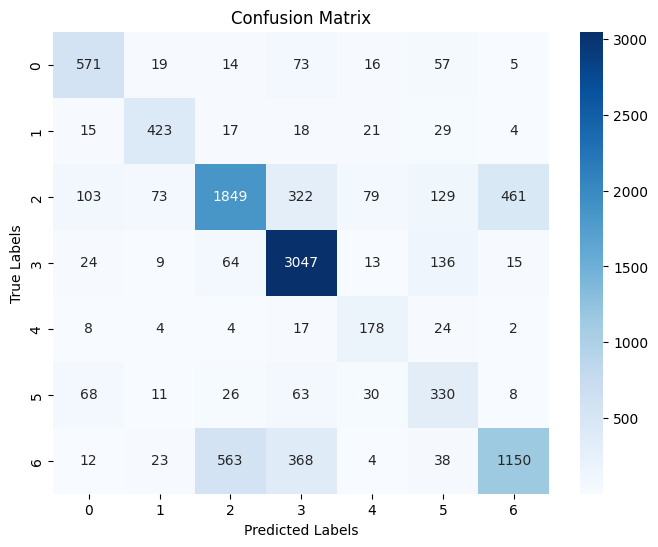

In [35]:
count_vec_boost(XGBClassifier, "processed_statement", **best_hyperparameters, verbose = False)

### Recreating the model to use the trained model for prediction or inference (e.g., testing on new unseen text).
Only purpose here is to get trained c_vectorizer and model objects in memory — which can be used later for predictions.

In [36]:
c_vectorizer = CountVectorizer(max_df = 1.0, max_features = 10000, ngram_range = (1, 3))
X_train_vector = c_vectorizer.fit_transform(X_train['processed_statement'])
X_test_vector = c_vectorizer.transform(X_test['processed_statement'])

model = XGBClassifier(**best_hyperparameters)
model.fit(X_train_vector, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
text = data['statement'].sample(1)
text_index = text.index
print(text_index, text.values[0])
text = text.values[0]

Index([2200], dtype='int64') Not in the mood, why not sleep


In [38]:
predict_new_text(text, c_vectorizer, model)

{'Suicidal': np.int64(3)}

In [39]:
data.loc[text_index]['status']

2200    3
Name: status, dtype: int64

### 4.2 TFIDF Vectorization + Model

In [40]:
# %%time
# pipe_boosting(vectorizer = TfidfVectorizer(),
# classifier = XGBClassifier(verbose = -1),
# X_grid = X_train['processed_statement'],
# y_grid = y_train)

In [41]:
best_params = {'learning_rate': 0.06, 'n_estimators': 200, 'max_df': 1.0, 'max_features': 2000, 'ngram_range': (1, 3)}

              precision    recall  f1-score   support

           0       0.73      0.76      0.75       755
           1       0.79      0.81      0.80       527
           2       0.77      0.55      0.64      3016
           3       0.80      0.92      0.85      3308
           4       0.52      0.79      0.63       237
           5       0.47      0.64      0.54       536
           6       0.63      0.63      0.63      2158

    accuracy                           0.72     10537
   macro avg       0.67      0.73      0.69     10537
weighted avg       0.73      0.72      0.72     10537



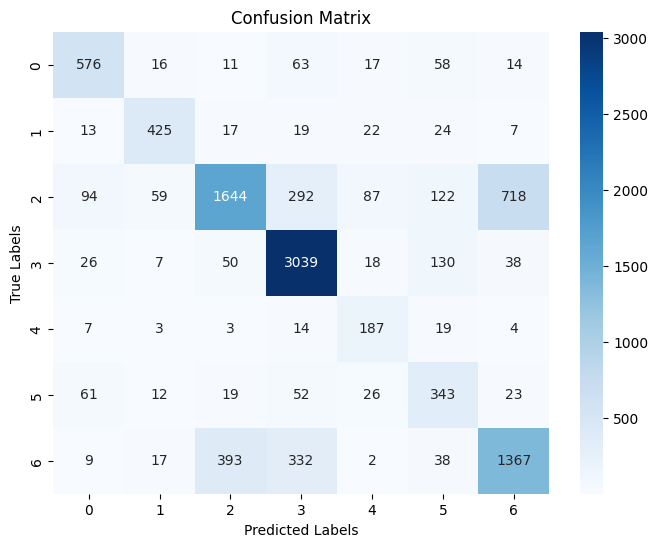

In [42]:
tfidf_vec_boost(XGBClassifier, "processed_statement", **best_params, verbose = False)

In [43]:
import gensim

In [44]:
wv_model = gensim.models.Word2Vec(sentences = X_train['processed_statement'], vector_size=100, window=5, min_count=2, workers=4)

In [45]:
def document_vector(doc):
    doc = [word for word in doc if word in wv_model.wv.key_to_index]
    if len(doc) > 0:
        return np.mean(wv_model.wv[doc], axis = 0)
    else:
        return np.zeros(wv_model.vector_size)

In [46]:
X_train_vector = X_train['processed_statement'].apply(document_vector)
X_test_vector = X_test['processed_statement'].apply(document_vector)

In [47]:
# Convert embeddings to numpy arrays
X_train_vector1 = np.array(X_train_vector.tolist())
X_test_vector1 = np.array(X_test_vector.tolist())

# Initialize and train the XGBoost classifier
xgb_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.07)
xgb_model.fit(X_train_vector1, y_train)

# Predict and evaluate
y_pred = xgb_model.predict(X_test_vector1)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.29      0.42      0.35       755
           1       0.21      0.47      0.29       527
           2       0.52      0.36      0.43      3016
           3       0.80      0.80      0.80      3308
           4       0.11      0.46      0.18       237
           5       0.17      0.39      0.24       536
           6       0.47      0.16      0.24      2158

    accuracy                           0.47     10537
   macro avg       0.37      0.44      0.36     10537
weighted avg       0.54      0.47      0.48     10537



In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from gensim.models import Word2Vec
from tqdm import tqdm

In [49]:
# Suppose your dataframe is 'train'
X = train_df["processed_statement"].tolist()
y = train_df["status"].tolist()

# Label encoding
le = LabelEncoder()
y = le.fit_transform(y)

# Tokenization
def tokenize(text):
    return text.split()

tokenized_X = [tokenize(x) for x in X]

# Word2Vec Embeddings
word2vec = Word2Vec(sentences=tokenized_X, vector_size=100, window=5, min_count=1, workers=4)

# Build vocabulary
word2idx = {word: idx + 1 for idx, word in enumerate(word2vec.wv.index_to_key)}  # +1 for padding
idx2word = {idx: word for word, idx in word2idx.items()}

# Create embedding matrix
embedding_dim = 100
embedding_matrix = np.zeros((len(word2idx) + 1, embedding_dim))
for word, idx in word2idx.items():
    embedding_matrix[idx] = word2vec.wv[word]

In [50]:
def text_to_seq(tokens):
    return [word2idx.get(word, 0) for word in tokens]

sequences = [text_to_seq(tokens) for tokens in tokenized_X]

max_len = 100
padded_sequences = [torch.tensor(seq[:max_len]) if len(seq) >= max_len 
                    else torch.cat([torch.tensor(seq), torch.zeros(max_len - len(seq), dtype=torch.long)]) 
                    for seq in sequences]

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)

In [51]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [52]:
class BiLSTMModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, output_dim=7):
        super(BiLSTMModel, self).__init__()
        vocab_size, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix), freeze=True)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out

In [53]:
class CNNModel(nn.Module):
    def __init__(self, embedding_matrix, num_filters=128, output_dim=7):
        super(CNNModel, self).__init__()
        vocab_size, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix), freeze=True)
        self.conv1 = nn.Conv1d(embedding_dim, num_filters, kernel_size=5)
        self.conv2 = nn.Conv1d(num_filters, 64, kernel_size=5)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(64, output_dim)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x).squeeze(2)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [54]:
class CNNLSTMModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, output_dim=7):
        super(CNNLSTMModel, self).__init__()
        vocab_size, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix), freeze=True)
        self.conv = nn.Conv1d(embedding_dim, 128, kernel_size=5)
        self.pool = nn.MaxPool1d(2)
        self.lstm = nn.LSTM(128, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = x.permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        x = self.fc(h[-1])
        return x

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BiLSTMModel(embedding_matrix).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in tqdm(train_loader):
        # Ensure correct type and device
        X_batch = X_batch.long().to(device)
        y_batch = y_batch.long().to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

# ---------------------------
# Evaluation Phase
# ---------------------------
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.long().to(device)
        y_batch = y_batch.long().to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [01:13<00:00, 16.00it/s]


Epoch [1/10] - Loss: 1.6391


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [01:05<00:00, 17.86it/s]


Epoch [2/10] - Loss: 0.8832


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [01:04<00:00, 18.19it/s]


Epoch [3/10] - Loss: 0.6302


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [01:03<00:00, 18.52it/s]


Epoch [4/10] - Loss: 0.5033


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [01:03<00:00, 18.48it/s]


Epoch [5/10] - Loss: 0.4205


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [01:03<00:00, 18.50it/s]


Epoch [6/10] - Loss: 0.3668


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [01:08<00:00, 17.10it/s]


Epoch [7/10] - Loss: 0.3247


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [01:13<00:00, 16.06it/s]


Epoch [8/10] - Loss: 0.2966


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [01:05<00:00, 18.03it/s]


Epoch [9/10] - Loss: 0.2731


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [01:11<00:00, 16.42it/s]


Epoch [10/10] - Loss: 0.2570



Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      3050
           1       0.97      0.95      0.96      2999
           2       0.69      0.66      0.67      2491
           3       0.88      0.91      0.89      2561
           4       0.98      0.98      0.98      2949
           5       0.91      0.97      0.94      3031
           6       0.63      0.54      0.58      1703

    accuracy                           0.88     18784
   macro avg       0.86      0.85      0.85     18784
weighted avg       0.88      0.88      0.88     18784



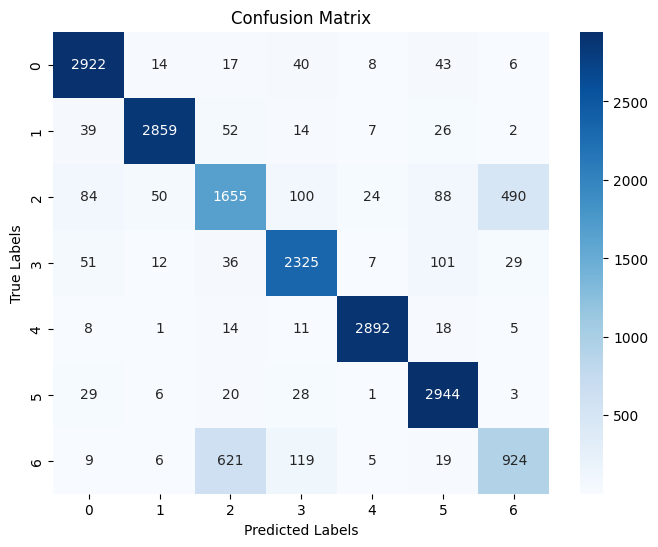

In [56]:
# Print classification metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[str(c) for c in le.classes_]))

# Compute and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = sorted(set(y_true))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNLSTMModel(embedding_matrix).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in tqdm(train_loader):
        # Ensure correct type and device
        X_batch = X_batch.long().to(device)
        y_batch = y_batch.long().to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

# ---------------------------
# Evaluation Phase
# ---------------------------
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.long().to(device)
        y_batch = y_batch.long().to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:27<00:00, 42.63it/s]


Epoch [1/10] - Loss: 0.9445


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:27<00:00, 42.90it/s]


Epoch [2/10] - Loss: 0.4800


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:26<00:00, 43.80it/s]


Epoch [3/10] - Loss: 0.3515


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:26<00:00, 43.97it/s]


Epoch [4/10] - Loss: 0.2914


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:26<00:00, 43.91it/s]


Epoch [5/10] - Loss: 0.2521


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:26<00:00, 43.79it/s]


Epoch [6/10] - Loss: 0.2228


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:27<00:00, 41.98it/s]


Epoch [7/10] - Loss: 0.1971


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:23<00:00, 49.29it/s]


Epoch [8/10] - Loss: 0.1819


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:22<00:00, 51.65it/s]


Epoch [9/10] - Loss: 0.1649


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:24<00:00, 48.26it/s]


Epoch [10/10] - Loss: 0.1502



Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      3050
           1       0.97      0.95      0.96      2999
           2       0.67      0.66      0.66      2491
           3       0.90      0.87      0.88      2561
           4       0.98      0.97      0.97      2949
           5       0.91      0.96      0.94      3031
           6       0.62      0.59      0.61      1703

    accuracy                           0.87     18784
   macro avg       0.85      0.85      0.85     18784
weighted avg       0.87      0.87      0.87     18784



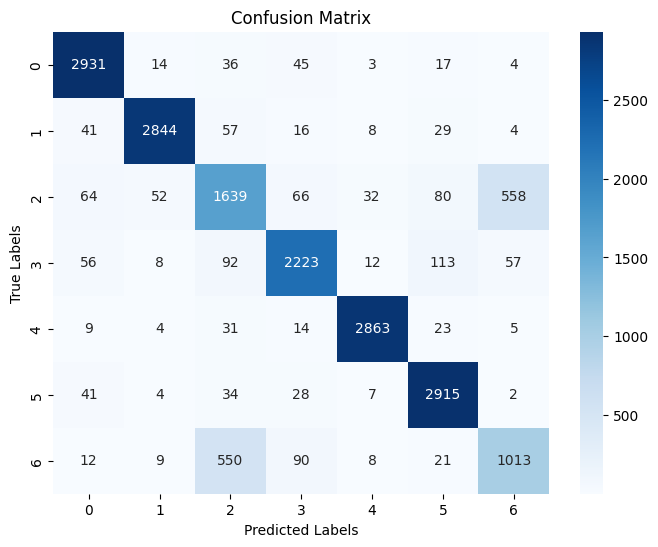

In [58]:
# Print classification metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[str(c) for c in le.classes_]))

# Compute and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = sorted(set(y_true))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel(embedding_matrix).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in tqdm(train_loader):
        # Ensure correct type and device
        X_batch = X_batch.long().to(device)
        y_batch = y_batch.long().to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

# ---------------------------
# Evaluation Phase
# ---------------------------
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.long().to(device)
        y_batch = y_batch.long().to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:13<00:00, 84.97it/s]


Epoch [1/10] - Loss: 0.9851


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:14<00:00, 83.58it/s]


Epoch [2/10] - Loss: 0.7172


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:15<00:00, 73.82it/s]


Epoch [3/10] - Loss: 0.6093


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:16<00:00, 69.71it/s]


Epoch [4/10] - Loss: 0.5382


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:17<00:00, 66.43it/s]


Epoch [5/10] - Loss: 0.4922


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:17<00:00, 67.21it/s]


Epoch [6/10] - Loss: 0.4591


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:17<00:00, 67.11it/s]


Epoch [7/10] - Loss: 0.4345


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:14<00:00, 78.66it/s]


Epoch [8/10] - Loss: 0.4148


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:14<00:00, 78.92it/s]


Epoch [9/10] - Loss: 0.4000


100%|██████████████████████████████████████████████████████████████████████████████| 1174/1174 [00:15<00:00, 75.87it/s]


Epoch [10/10] - Loss: 0.3818



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      3050
           1       0.97      0.94      0.95      2999
           2       0.71      0.51      0.59      2491
           3       0.82      0.91      0.86      2561
           4       0.97      0.97      0.97      2949
           5       0.89      0.96      0.92      3031
           6       0.57      0.68      0.62      1703

    accuracy                           0.86     18784
   macro avg       0.84      0.84      0.84     18784
weighted avg       0.86      0.86      0.86     18784



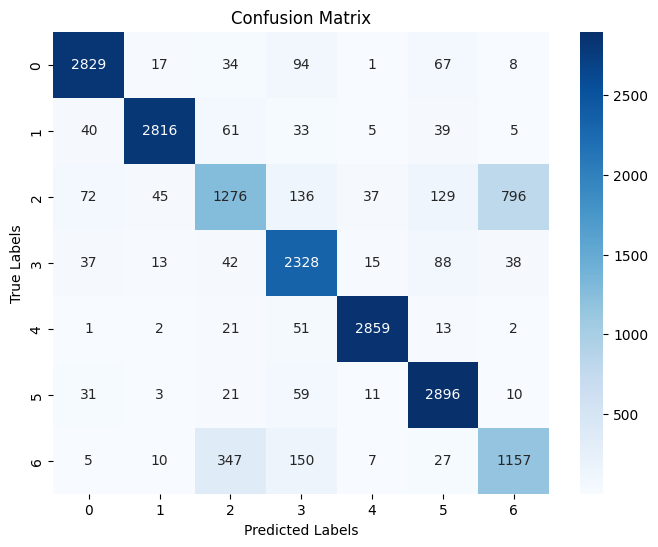

In [60]:
# Print classification metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[str(c) for c in le.classes_]))

# Compute and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = sorted(set(y_true))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()